In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import os
import json

import sys
sys.path.append('../src')
from traffic_sim import *
from mpc_metanet import mpc_find_vsl

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [2]:
def smooth_inflow(inflow, window_size=2):
    # Create averaging kernel
    kernel = np.ones(window_size) / window_size

    # Compute asymmetric padding for even window sizes
    pad_left = window_size // 2
    pad_right = window_size - pad_left - 1

    # Pad using boundary values (edge padding)
    if inflow.ndim == 1:
        padded = np.pad(inflow, (pad_left, pad_right), mode='edge')
    else:
        padded = np.pad(inflow, ((pad_left, pad_right), (0, 0)), mode='edge')

    # Convolve along time dimension
    smoothed = np.apply_along_axis(
        lambda m: np.convolve(m, kernel, mode="valid"), axis=0, arr=padded
    )
    return smoothed

## Data and calibration loading

In [3]:
# Define parameters for METANET Model
L = 0.4
time_step = 10/3600
total_time = 1  # in hours
start_time = 0  # in hours
start_time_step = int(start_time / time_step)

In [4]:
# Read in the data
data_path = "/Users/shreyaar/Desktop/PhD/research/MPC/data/i24/i24_11_30"
calibration_id = "calibration_static/fixed_ramping"
results_path = f"/Users/shreyaar/Desktop/PhD/research/MPC/results/i24/i24_11_30/{calibration_id}/safety_sweep"

calibration_interval = None  # None if static, otherwise, parameter interval for dynamic calibration (in time steps)
cal_path = f'{data_path}/{calibration_id}' if calibration_interval is None else f'{data_path}/{calibration_id}/control_h_{calibration_interval}'
if calibration_interval is not None:
    results_path += f"/control_h_{calibration_interval}"

# Assert data exists
assert os.path.exists(cal_path), f"Calibration parameters not found at {cal_path}"
assert os.path.exists(f'{data_path}/v_hat.npy') and os.path.exists(f'{data_path}/rho_hat.npy'), f"Data not found at {data_path}"

In [5]:
density_data = np.load(f'{data_path}/rho_hat.npy')
flow_data = np.load(f'{data_path}/q_hat.npy')
density_data = np.where(density_data == 0.0, 1e-3, density_data)
flow_data = np.where(flow_data == 0.0, 1e-3, flow_data)
velocity_data = flow_data/density_data
print("Time steps, num segments (including boundary cond.):", density_data.shape)

true_density_initial = density_data[start_time_step, 1:-1].reshape(-1)
true_velocity_initial = velocity_data[start_time_step, 1:-1].reshape(-1)

downstream_density = density_data[0:, -1].reshape(-1)
data_inflow = (velocity_data[0:, 0] * density_data[0:, 0]).reshape(-1)
data_inflow = smooth_inflow(data_inflow, window_size=2)
downstream_density = smooth_inflow(downstream_density, window_size=2)

print("time steps:", downstream_density.shape)
print("num segments:", true_density_initial.shape)

Time steps, num segments (including boundary cond.): (360, 16)
time steps: (360,)
num segments: (14,)


In [6]:
time_steps = downstream_density.shape[0]
num_segments = density_data.shape[1] - 2  # Subtract 2 for the boundary segments
total_distance = L * num_segments  # km
print("sim_time:", time_step * downstream_density.shape[0] * 60, "minutes")
print("length of highway:", total_distance, "km")

lane_counts = np.load(f'{cal_path}/num_lanes.npy').reshape(-1) if calibration_interval is None else np.load(f'{cal_path}/params_1/num_lanes.npy').reshape(-1)
lane_dict = {i: lane_counts[i] for i in range(num_segments)}

velocity_data = velocity_data[:, 1:-1]  # remove boundary conditions for plotting
flow_data = flow_data[:, 1:-1]
density_data = density_data[:, 1:-1]

# Normalize densities by lane counts to get per-lane densities
downstream_density = downstream_density / lane_dict[num_segments - 1]
true_density_initial = true_density_initial / lane_counts
density_data = density_data / lane_counts

sim_time: 60.0 minutes
length of highway: 5.6000000000000005 km


In [7]:
from param_loader import METANET_Params

subfolders = [
    f for f in os.listdir(cal_path)
    if os.path.isdir(os.path.join(cal_path, f)) and f.startswith("params_")
]

if subfolders:
    print(f"Dynamic parameters detected: {len(subfolders)} subfolder(s) found")
    control_h = time_steps // len(subfolders)
    model_params = METANET_Params(path=f"{data_path}/{calibration_id}", control_h=control_h, num_timesteps=time_steps, num_segments=num_segments).get_params()
else:
    print("No dynamic parameter subfolders found — using static calibration parameters")
    model_params = METANET_Params(path=cal_path, num_timesteps=time_steps, num_segments=num_segments).get_params()

No dynamic parameter subfolders found — using static calibration parameters


## Baseline (no control) simulation

This is the "before control" reference every swept configuration gets compared against.

In [8]:
init_state = (true_density_initial,
              true_velocity_initial,
              data_inflow[start_time_step],
              0)

vsl_baseline = np.ones((downstream_density.shape[0], num_segments)) * 150
p_baseline, v_baseline, queue_baseline, tts_baseline = run_metanet_sim(
    time_step, L, init_state,
    data_inflow[start_time:],
    downstream_density[start_time:],
    model_params,
    lanes=lane_dict,
    vsl_speeds=vsl_baseline,
    plotting=True,
    real_data=False
)

print("TTS (no control, VSL=150):", tts_baseline)

TTS (no control, VSL=150): 550.6291368412816


## MPC configuration and safety-constraint sweep

`hold_len`, `control_horizon`, and `pred_horizon` are fixed; `safety_temporal` (max VSL change per time step) and `safety_spatial` (max VSL difference between adjacent segments) are swept over a grid.

In [94]:
pred_horizon = 40      # in time steps
control_horizon = 5    # in time steps
hold_len = 1

opt_horizon = time_steps + pred_horizon - control_horizon
downstream_density_mpc = np.append(downstream_density, downstream_density[-1])
inflow_mpc = np.append(data_inflow, data_inflow[-1])
while len(downstream_density_mpc) <= opt_horizon + 1:
    downstream_density_mpc = np.append(downstream_density_mpc, downstream_density[-1])
    inflow_mpc = np.append(inflow_mpc, data_inflow[-1])

print(data_inflow.shape, downstream_density.shape)
print(downstream_density_mpc.shape, inflow_mpc.shape, time_steps)

(360,) (360,)
(397,) (397,) 360


In [107]:
control_zone = [i for i in range(2, num_segments)]

# Placeholder grid — adjust based on how aggressive/conservative you want VSL changes to be.
# safety_temporal: max VSL change (km/hr) allowed between consecutive 10s time steps
# safety_spatial:  max VSL difference (km/hr) allowed between adjacent segments at the same time
safety_temporal_values = [2] #[1, 2, 3, 4, 5, 7.5, 10, 15, 20]
safety_spatial_values = [1, 2, 3, 4, 5, 7.5, 10, 15, 20]

In [108]:
def plot_before_after(v_before, tts_before, v_after, tts_after, label_before, label_after):
    vmin = min(np.min(velocity_data), v_before.min(), v_after.min())
    vmax = 150

    fig, axs = plt.subplots(1, 2, figsize=(16, 6))

    im0 = axs[0].imshow(v_before.T, cmap='RdYlGn', aspect='auto', interpolation='none', vmin=vmin, vmax=vmax)
    axs[0].set_title(f'{label_before} (TTS {np.round(tts_before, 2)})')
    axs[0].set_xlabel('Time step')
    axs[0].set_ylabel('Segment index')
    axs[0].invert_yaxis()
    axs[0].xaxis.set_ticks_position('bottom')
    cbar0 = fig.colorbar(im0, ax=axs[0], fraction=0.046, pad=0.04)
    cbar0.set_label('Velocity (km/hr)')

    im1 = axs[1].imshow(v_after.T, cmap='RdYlGn', aspect='auto', interpolation='none', vmin=vmin, vmax=vmax)
    axs[1].set_title(f'{label_after} (TTS {np.round(tts_after, 2)})')
    axs[1].set_xlabel('Time step')
    axs[1].invert_yaxis()
    axs[1].xaxis.set_ticks_position('bottom')
    cbar1 = fig.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04)
    cbar1.set_label('Velocity (km/hr)')

    plt.tight_layout()
    plt.show()

In [109]:
print(np.load(f'{results_path}/optimal_vsl_temp1_spat10.npy').shape)

(360, 14)


In [110]:
import logging 
logging.getLogger('pyomo.core').setLevel(logging.ERROR)


=== safety_temporal=2, safety_spatial=20 ===
[MPC] t = 0
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 5
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 10
Density mismatch: 0.0000, Velocity mismatch: 0.0001
[MPC] t = 15
Density mismatch: 0.0000, Velocity mismatch: 0.0001
[MPC] t = 20
Density mismatch: 0.0000, Velocity mismatch: 0.0002
[MPC] t = 25
Density mismatch: 0.0000, Velocity mismatch: 0.0004
[MPC] t = 30
Density mismatch: 0.0000, Velocity mismatch: 0.0001
[MPC] t = 35
Density mismatch: 0.0000, Velocity mismatch: 0.0004
[MPC] t = 40
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 45
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 50
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 55
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 60
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 65
Density mismatch: 0.0000, Velocity mismatch: 0.0001
[MPC] t = 70
Density mismatch: 0.0000, Velocit

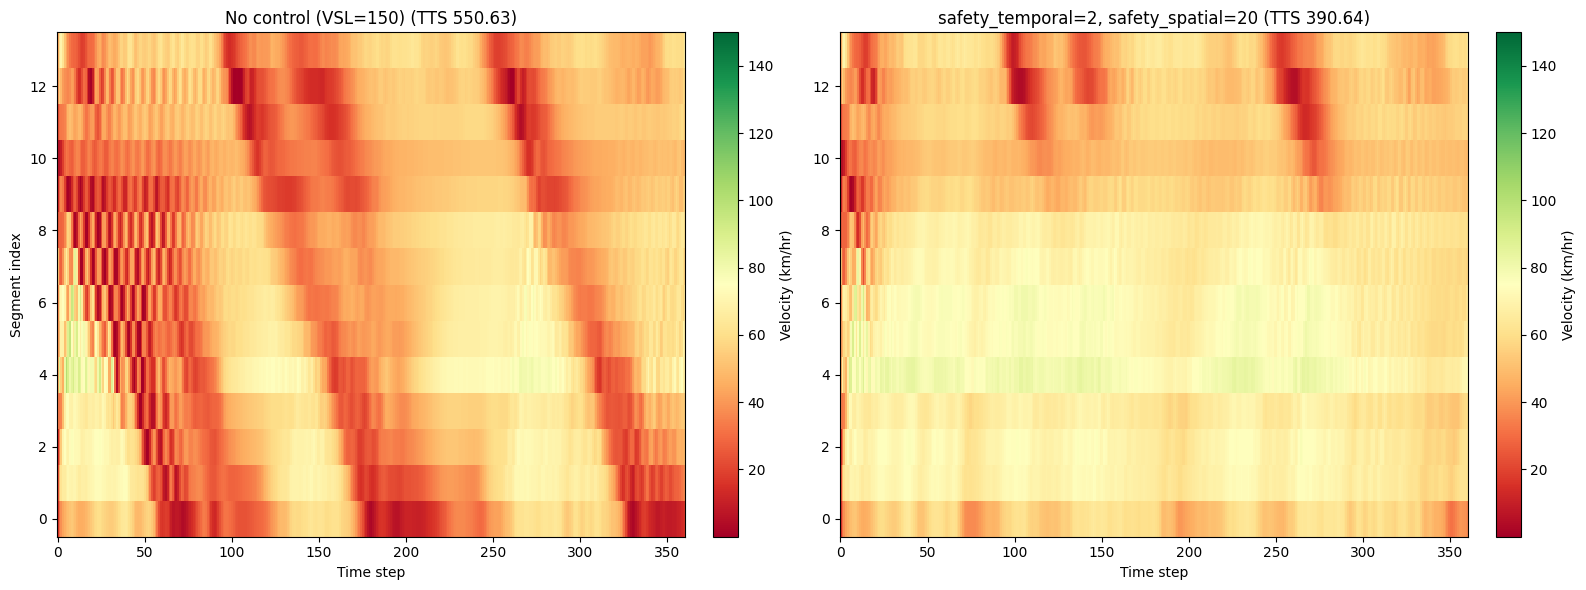


=== safety_temporal=2, safety_spatial=15 ===
[MPC] t = 0
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 5
Density mismatch: 0.0000, Velocity mismatch: 0.0001
[MPC] t = 10
Density mismatch: 0.0000, Velocity mismatch: 0.0001
[MPC] t = 15
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 20
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 25
Density mismatch: 0.0000, Velocity mismatch: 0.0004
[MPC] t = 30
Density mismatch: 0.0000, Velocity mismatch: 0.0001
[MPC] t = 35
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 40
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 45
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 50
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 55
Density mismatch: 0.0000, Velocity mismatch: 0.0001
[MPC] t = 60
Density mismatch: 0.0000, Velocity mismatch: 0.0002
[MPC] t = 65
Density mismatch: 0.0000, Velocity mismatch: 0.0002
[MPC] t = 70
Density mismatch: 0.0000, Velocit

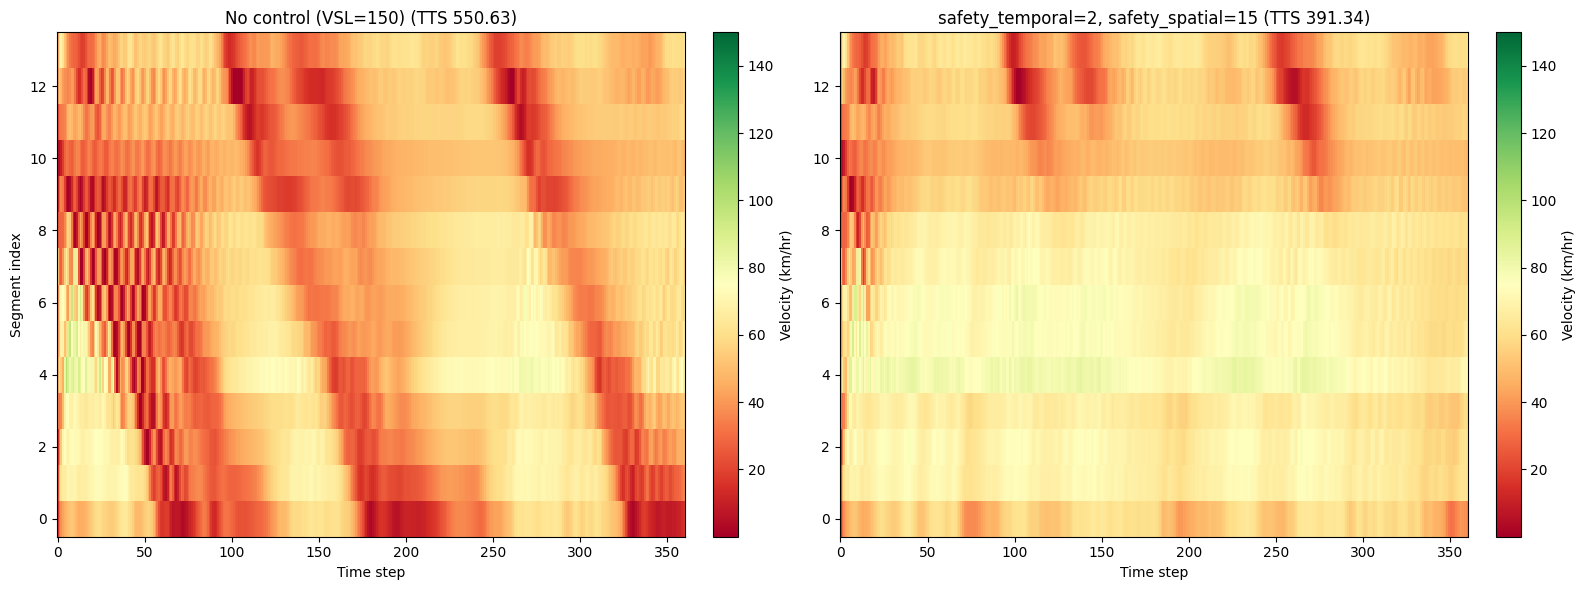


=== safety_temporal=2, safety_spatial=10 ===
[MPC] t = 0
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 5
Density mismatch: 0.0000, Velocity mismatch: 0.0001
[MPC] t = 10
Density mismatch: 0.0000, Velocity mismatch: 0.0001
[MPC] t = 15
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 20
Density mismatch: 0.0000, Velocity mismatch: 0.0001
[MPC] t = 25
Density mismatch: 0.0001, Velocity mismatch: 0.0005
[MPC] t = 30
Density mismatch: 0.0000, Velocity mismatch: 0.0001
[MPC] t = 35
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 40
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 45
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 50
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 55
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 60
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 65
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 70
Density mismatch: 0.0000, Velocit

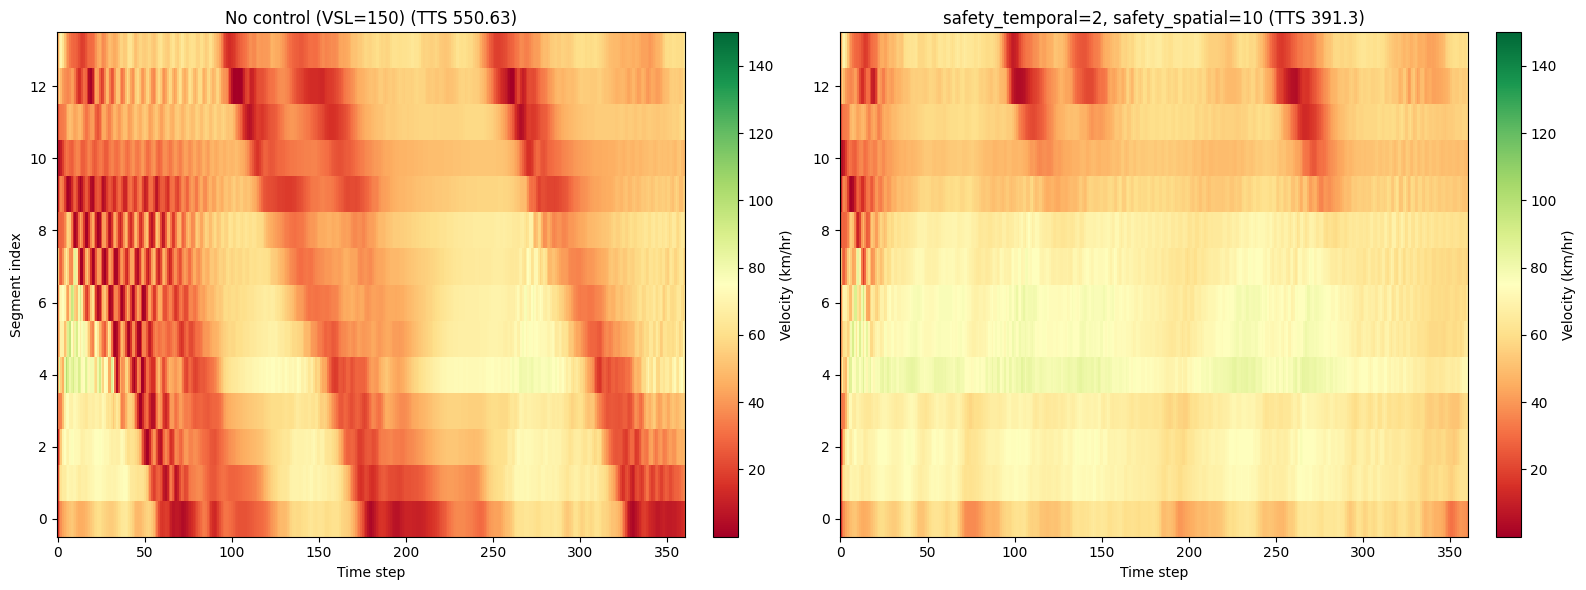


=== safety_temporal=2, safety_spatial=7.5 ===
[MPC] t = 0
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 5
Density mismatch: 0.0000, Velocity mismatch: 0.0001
[MPC] t = 10
Density mismatch: 0.0000, Velocity mismatch: 0.0001
[MPC] t = 15
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 20
Density mismatch: 0.0000, Velocity mismatch: 0.0002
[MPC] t = 25
Density mismatch: 0.0000, Velocity mismatch: 0.0004
[MPC] t = 30
Density mismatch: 0.0000, Velocity mismatch: 0.0002
[MPC] t = 35
Density mismatch: 0.0000, Velocity mismatch: 0.0002
[MPC] t = 40
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 45
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 50
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 55
Density mismatch: 0.0000, Velocity mismatch: 0.0002
[MPC] t = 60
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 65
Density mismatch: 0.0000, Velocity mismatch: 0.0001
[MPC] t = 70
Density mismatch: 0.0000, Veloci

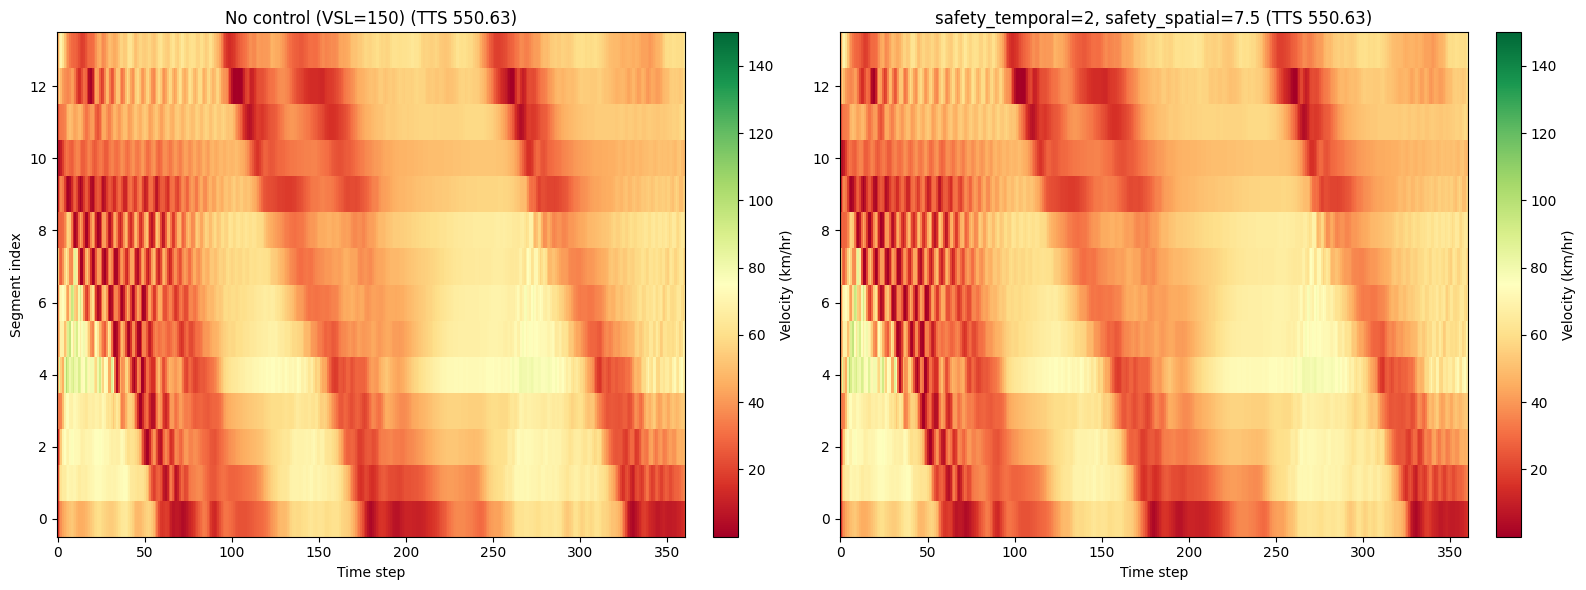


=== safety_temporal=2, safety_spatial=5 ===
[MPC] t = 0
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 5
Density mismatch: 0.0000, Velocity mismatch: 0.0001
[MPC] t = 10
Density mismatch: 0.0000, Velocity mismatch: 0.0001
[MPC] t = 15
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 20
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 25
Density mismatch: 0.0001, Velocity mismatch: 0.0005
[MPC] t = 30
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 35
Density mismatch: 0.0000, Velocity mismatch: 0.0002
[MPC] t = 40
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 45
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 50
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 55
Density mismatch: 0.0000, Velocity mismatch: 0.0001
[MPC] t = 60
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 65
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 70
Density mismatch: 0.0000, Velocity

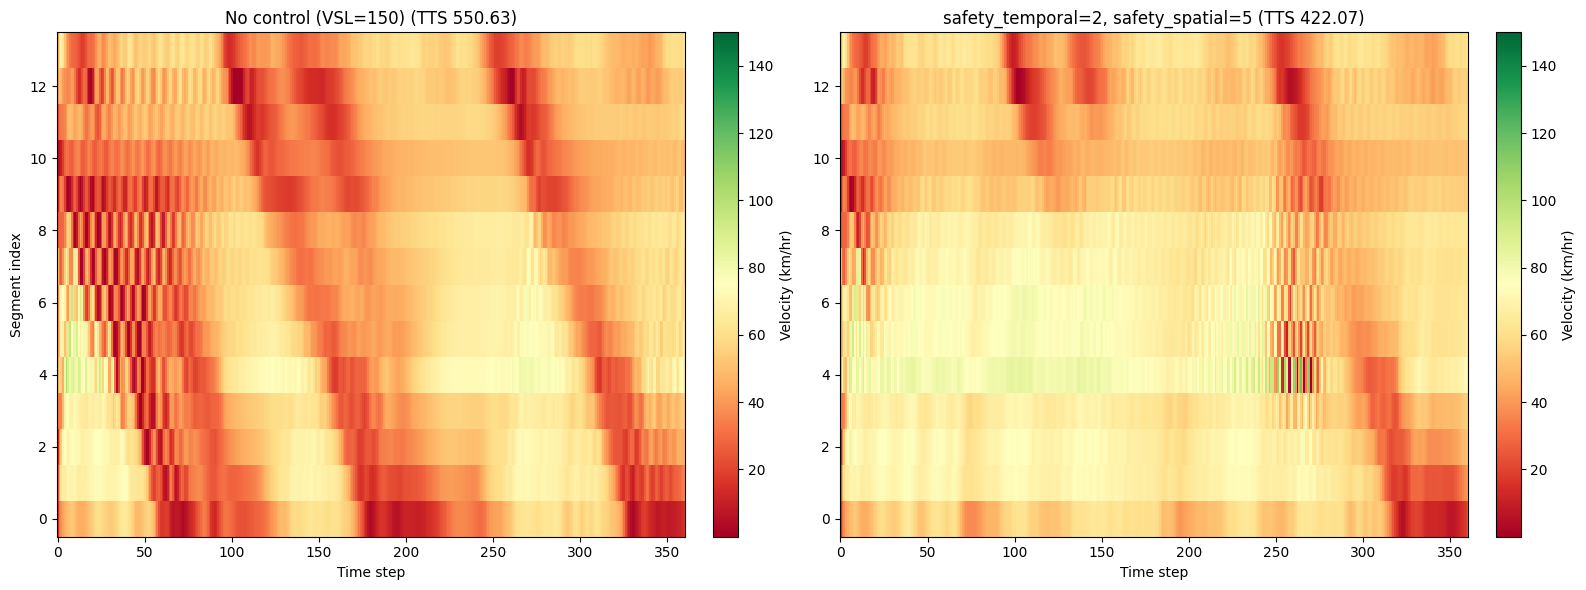


=== safety_temporal=2, safety_spatial=4 ===
[MPC] t = 0
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 5
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 10
Density mismatch: 0.0000, Velocity mismatch: 0.0001
[MPC] t = 15
Density mismatch: 0.0000, Velocity mismatch: 0.0001
[MPC] t = 20
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 25
Density mismatch: 0.0000, Velocity mismatch: 0.0001
[MPC] t = 30
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 35
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 40
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 45
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 50
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 55
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 60
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 65
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 70
Density mismatch: 0.0000, Velocity

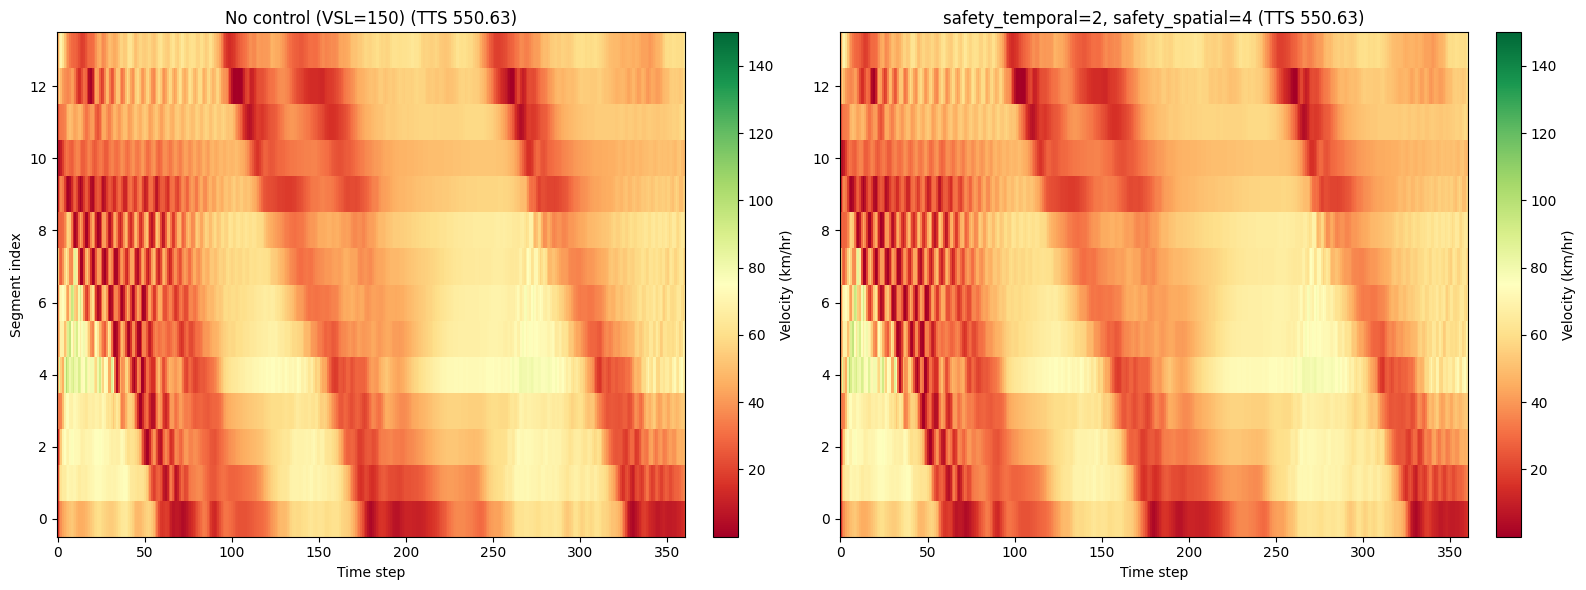


=== safety_temporal=2, safety_spatial=3 ===
[MPC] t = 0
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 5
Density mismatch: 0.0000, Velocity mismatch: 0.0001
[MPC] t = 10
Density mismatch: 0.0000, Velocity mismatch: 0.0001
[MPC] t = 15
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 20
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 25
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 30
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 35
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 40
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 45
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 50
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 55
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 60
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 65
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 70
Density mismatch: 0.0000, Velocity

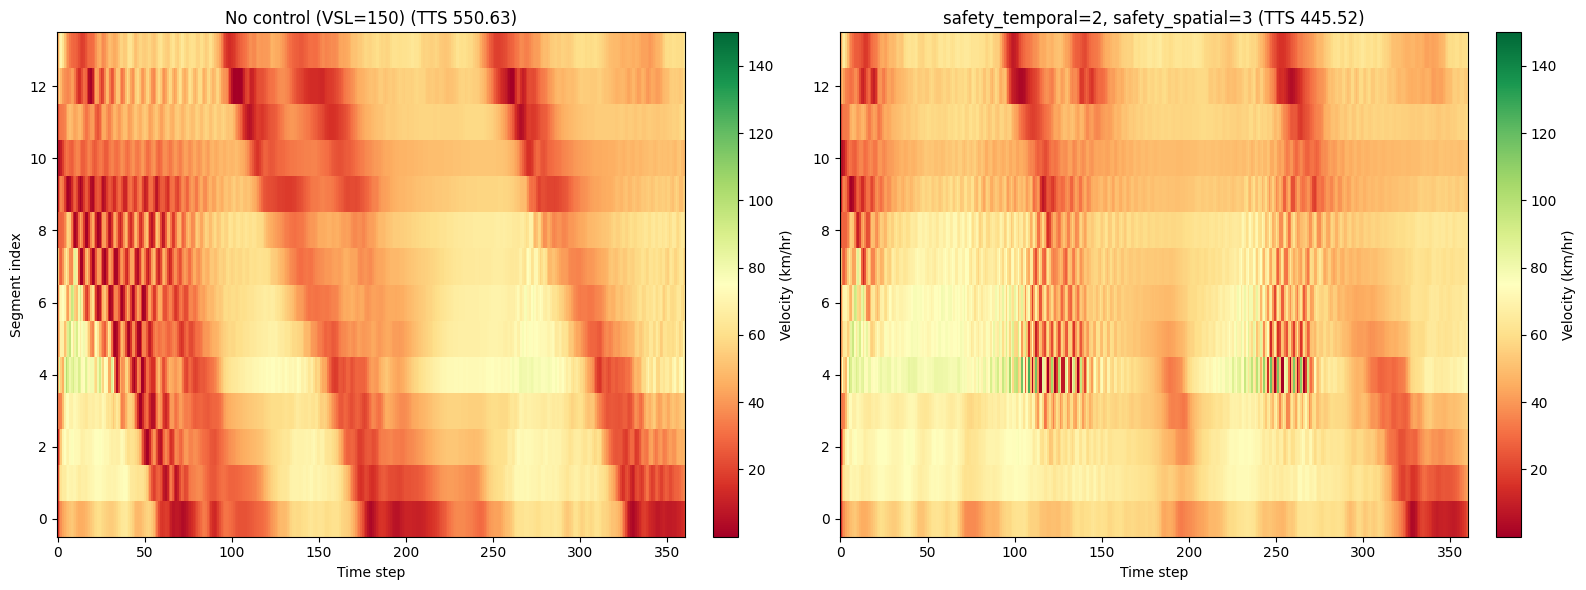


=== safety_temporal=2, safety_spatial=2 ===
[MPC] t = 0
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 5
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 10
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 15
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 20
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 25
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 30
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 35
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 40
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 45
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 50
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 55
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 60
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 65
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 70
Density mismatch: 0.0000, Velocity

In [ ]:
os.makedirs(results_path, exist_ok=True)

for safety_temporal in reversed(safety_temporal_values):
    # init_path = None
    for safety_spatial in reversed(safety_spatial_values):
        init_path = f"{results_path}/optimal_vsl_temp1_spat{safety_spatial}.npy"
        # if f'optimal_vsl_temp{safety_temporal}_spat{safety_spatial}.npy' in os.listdir(results_path):
        #     print(f"Skipping safety_temporal={safety_temporal}, safety_spatial={safety_spatial} (already exists)")
        #     # init_path = f'{results_path}/optimal_vsl_temp{safety_temporal}_spat{safety_spatial}.npy'
        #     continue

        vsl_opt_config = {
            "hold_length": hold_len,
            "control_changepoints": None,
            "safety_temporal": safety_temporal,
            "safety_spatial": safety_spatial,
            "speed_lb": 0,
            "warmup_time": 0,
            "control_zone": control_zone,
            "control_one_segment": None,
            "initialize_vsl":np.load(init_path),
            "init_fixed": ["adaptive", 120, 100, 80, 60], #"adaptive",
            "tee": False,
            "pred_horizon": pred_horizon,
            "control_horizon": control_horizon
        }

        print(f"\n=== safety_temporal={safety_temporal}, safety_spatial={safety_spatial} ===")
        optimal_vsl = mpc_find_vsl(opt_horizon, inflow_mpc[start_time:], downstream_density_mpc[start_time:], lane_dict,
                                T=time_step, l=L, num_segments=num_segments, init_state=init_state,
                                params=model_params, verbose=True, v_fd_penalty=1e14, **vsl_opt_config)

        path_id = f"optimal_vsl_temp{safety_temporal}_spat{safety_spatial}"
        np.save(f'{results_path}/{path_id}.npy', optimal_vsl)
        if vsl_opt_config["initialize_vsl"] is not None:
            vsl_opt_config["initialize_vsl"] = f"loaded from file {init_path}"
        with open(f'{results_path}/{path_id}_config.json', "w") as file:
            json.dump(vsl_opt_config, file, indent=4)

        # Simulate forward with the optimized VSL to get the "after control" trajectory
        p_after, v_after, queue_after, tts_after = run_metanet_sim(
            time_step, L, init_state,
            data_inflow[start_time:],
            downstream_density[start_time:],
            model_params,
            lanes=lane_dict,
            vsl_speeds=optimal_vsl,
            plotting=True,
            real_data=False
        )

        print(f"TTS (no control):                                                  {tts_baseline}")
        print(f"TTS (safety_temporal={safety_temporal}, safety_spatial={safety_spatial}): {tts_after}")

        plot_before_after(v_baseline, tts_baseline, v_after, tts_after,
                           "No control (VSL=150)",
                           f"safety_temporal={safety_temporal}, safety_spatial={safety_spatial}")
        
        # init_path = f'{results_path}/optimal_vsl_temp{safety_temporal}_spat{safety_spatial}.npy'